# Controlled Scenario Demo — SingleGNBHeuristicAgent

Runs three fixed-bias episodes and traces **Gate-1** (A3 offset) and **Gate-2** (handover budget) at every step.

## PRB load: demand (static) vs window average (dynamic)

| Source | Method | What it measures | Changes with handovers? |
|--------|--------|------------------|--------------------------|
| `base_env.get_slice_loads()` | reads `ue.prbs` | **PRB demand** — seeded each step to scenario target | **No** — demand is constant by design |
| `base_env.get_window_average_slice_loads()` | accumulates `ue.useful_prbs` | **Physical utilization** from radio scheduler | **Yes** — depends on UE count, SINR, scheduler |

We use `get_slice_loads()` (PRB demand) for load tracking because the traffic demand is held **constant** by `_seed_case_prbs()` every step — this is the signal the upper expert uses.

The window average is shown as reference only (it saturates to ~1.0 in the offload scenario because the radio scheduler is busy).

---
**Scenarios**

| Scenario | Bias | Expected behaviour |
|----------|------|--------------------|
| `FIXED_EMBB_OFFLOAD` | B = −1.0 | source PRB demand = 0.90 → Gate-1 opens, handovers happen |
| `FIXED_EMBB_RETAIN` | B = +1.0 | source PRB demand = 0.20 → A3 bar raised, no handovers |
| `FIXED_EMBB_RETAIN` | B = −1.0 (artificial) | source demand = 0.20 < safe=0.80 → **Gate-1 blocks** even with strong offload bias |

In [8]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from local_a3_training_env import LocalA3RuleBiasTrainingEnv
from local_a3_training_scenarios import (
    FIXED_EMBB_OFFLOAD_SNAPSHOT,
    FIXED_EMBB_RETAIN_SNAPSHOT,
)
from single_gnb_heuristic_agent import SingleGNBHeuristicAgent

SLICE     = "eMBB"
SAFE_LOAD = 0.80
N_STEPS   = 20

print("Imports OK")

Imports OK


---
## 1 — Environment & Agent Factory

In [9]:
def make_env(snapshot, seed=42):
    return LocalA3RuleBiasTrainingEnv(
        seed=seed,
        gnb_id=0,
        neighbor_ids=(1,),
        slice_types=(SLICE,),
        episode_steps=N_STEPS + 5,
        action_hold_steps=1,
        bias_hold_steps=N_STEPS + 5,
        max_offset_change_db=6.0,   # no rate-limit — cleaner demo
        balance_bias_cases=True,
        training_scenarios=(snapshot,),
        print_scenarios=False,
    )


def force_bias(env, bval):
    src = env.local_env.gnb_id
    nb  = env.local_env.neighbor_ids[0]
    env.local_env.set_global_bias({(src, nb, SLICE): float(bval), (nb, src, SLICE): 0.0})


def clamp_offsets(env, val=6.0):
    """Pre-set applied offsets to prevent spontaneous handovers during warmup."""
    for key in env.local_env._offsets:
        env.local_env._offsets[key] = float(val)


def warmup(env, agent, n=3):
    """3 retain-bias steps to populate PRB demand and window without losing UEs."""
    obs = env.local_env._build_observation()
    for _ in range(n):
        force_bias(env, +1.0)
        clamp_offsets(env, 6.0)
        a, _ = agent.predict(obs)
        clamp_offsets(env, 6.0)
        obs, _, done, trunc, _ = env.step(a)
        if done or trunc:
            obs, _ = env.reset(seed=42)
    return obs


def get_prb_demand(env):
    """PRB demand at source — seeded each step by _seed_case_prbs(), STATIC."""
    loads = env.base_env.get_slice_loads()
    return float(loads.get((0, SLICE), 0.0))


def get_window_load(env):
    """Physically utilized PRBs from radio scheduler — DYNAMIC."""
    wl = env.base_env.get_window_average_slice_loads()
    return float(wl.get((0, SLICE), 0.0))


def n_ues_src(env):
    return sum(
        1 for ue in env.base_env.get_all_ues()
        if ue.connected and ue.serving_gnb is not None and int(ue.serving_gnb) == 0
    )


def proto_offset(agent):
    """Gate-1 raw output — coordinated_neighbor_offsets() before smoothing."""
    return float(agent._compute_proto_offsets()[0])


print("Helpers defined")

Helpers defined


---
## 2 — Run All Three Scenarios

Each scenario records per-step:
- **`prb_demand`** — `get_slice_loads()` reading `ue.prbs` → constant per scenario (static demand)
- **`window_load`** — `get_window_average_slice_loads()` → dynamic radio utilization
- **`proto_offset`** — Gate-1 output (dB)
- **`budget`** — Gate-2 quota
- **`n_ues`** — UEs connected to gNB-0
- **`ho`** — handovers executed this step

In [10]:
SCENARIOS = [
    # (label,  snapshot,              bias,  description)
    ("OFFLOAD\n(B=−1.0)",  FIXED_EMBB_OFFLOAD_SNAPSHOT, -1.0,
     "source PRB demand = 0.90 > safe=0.80  →  Gate-1 opens, handovers happen"),
    ("RETAIN\n(B=+1.0)",   FIXED_EMBB_RETAIN_SNAPSHOT,  +1.0,
     "source PRB demand = 0.20 < safe=0.80  →  A3 bar raised, zero handovers"),
    ("GATE-1\nPROTECTION\n(B=−1.0 on safe src)", FIXED_EMBB_RETAIN_SNAPSHOT, -1.0,
     "source PRB demand = 0.20 < safe=0.80  →  Gate-1 blocks (source_pressure=0)"),
]

results = {}  # label → dict of lists

for label, snapshot, bval, desc in SCENARIOS:
    env   = make_env(snapshot, seed=42)
    agent = SingleGNBHeuristicAgent(env.local_env)
    env.reset(seed=42)
    agent.reset()
    obs = warmup(env, agent)

    nb = env.local_env.neighbor_ids[0]
    rec = {k: [] for k in ("prb_demand", "window_load", "proto_off", "budget", "n_ues", "ho")}

    for step in range(N_STEPS):
        force_bias(env, bval)
        a, _ = agent.predict(obs)

        demand = get_prb_demand(env)
        wload  = get_window_load(env)
        p_off  = proto_offset(agent)
        bgt    = agent._budgets.get((nb, SLICE), 0)
        n      = n_ues_src(env)

        ho_before = len(env.base_env.handover_events)
        obs, _, done, trunc, _ = env.step(a)
        ho_this = len(env.base_env.handover_events) - ho_before

        rec["prb_demand"].append(demand)
        rec["window_load"].append(wload)
        rec["proto_off"].append(p_off)
        rec["budget"].append(bgt)
        rec["n_ues"].append(n)
        rec["ho"].append(ho_this)

        if done or trunc:
            break

    env.close()
    results[label] = {"rec": rec, "bval": bval, "desc": desc}

    total_ho = sum(rec["ho"])
    print(f"  {label.replace(chr(10),' '):<45}  total_HOs={total_ho}  "
          f"demand_stable={len(set(round(v,3) for v in rec['prb_demand']))==1}")

print("\nAll scenarios done.")

  OFFLOAD (B=−1.0)                               total_HOs=25  demand_stable=True
  RETAIN (B=+1.0)                                total_HOs=0  demand_stable=True
  GATE-1 PROTECTION (B=−1.0 on safe src)         total_HOs=0  demand_stable=True

All scenarios done.


---
## 3 — Step-by-Step Trace Table

Shows: PRB demand (constant), window load, Gate-1 offset, Gate-2 budget, HOs per step.

In [11]:
SEP  = "─" * 88
HDR  = f"  {'step':>4}  {'prb_demand':>10}  {'window_load':>11}  {'proto_off':>10}  {'budget':>7}  {'n_ues':>5}  {'ho':>3}  note"

for label, snapshot, bval, desc in SCENARIOS:
    r   = results[label]["rec"]
    print(f"\n{'═'*88}")
    print(f"  {label.replace(chr(10),' ')}   bias={bval:+.1f}")
    print(f"  {desc}")
    print(f"{'═'*88}")
    print(HDR)
    print(SEP)
    for i, (dem, wl, po, bg, n, ho) in enumerate(
        zip(r["prb_demand"], r["window_load"], r["proto_off"],
            r["budget"], r["n_ues"], r["ho"]),
        start=1,
    ):
        overloaded = dem > SAFE_LOAD
        note = ""
        if bval < 0 and not overloaded:
            note = "← demand safe → Gate-1 blocks"
        elif ho > 0:
            note = f"↑ {ho} HO"
        elif bval > 0:
            note = "A3 bar raised"
        print(f"  {i:>4}  {dem:>10.3f}  {wl:>11.3f}  {po:>+10.1f}  {bg:>7}  {n:>5}  {ho:>3}  {note}")
    print(SEP)
    print(f"  TOTAL HOs: {sum(r['ho'])}   |  PRB demand constant: {len(set(round(v,3) for v in r['prb_demand']))==1}")


════════════════════════════════════════════════════════════════════════════════════════
  OFFLOAD (B=−1.0)   bias=-1.0
  source PRB demand = 0.90 > safe=0.80  →  Gate-1 opens, handovers happen
════════════════════════════════════════════════════════════════════════════════════════
  step  prb_demand  window_load   proto_off   budget  n_ues   ho  note
────────────────────────────────────────────────────────────────────────────────────────
     1       0.900        1.000        -6.0        1      4    0  
     2       0.900        1.000        -6.0        1      4    1  ↑ 1 HO
     3       0.900        1.000        -6.0        1      3    2  ↑ 2 HO
     4       0.900        1.000        +0.0        1      3    1  ↑ 1 HO
     5       0.900        1.000        -6.0        1      4    2  ↑ 2 HO
     6       0.900        1.000        -6.0        1      4    1  ↑ 1 HO
     7       0.900        1.000        -6.0        1      3    2  ↑ 2 HO
     8       0.900        1.000        -6.0        

---
## 4 — Plots: PRB Demand vs Window Load, Offset, Budget, Handovers

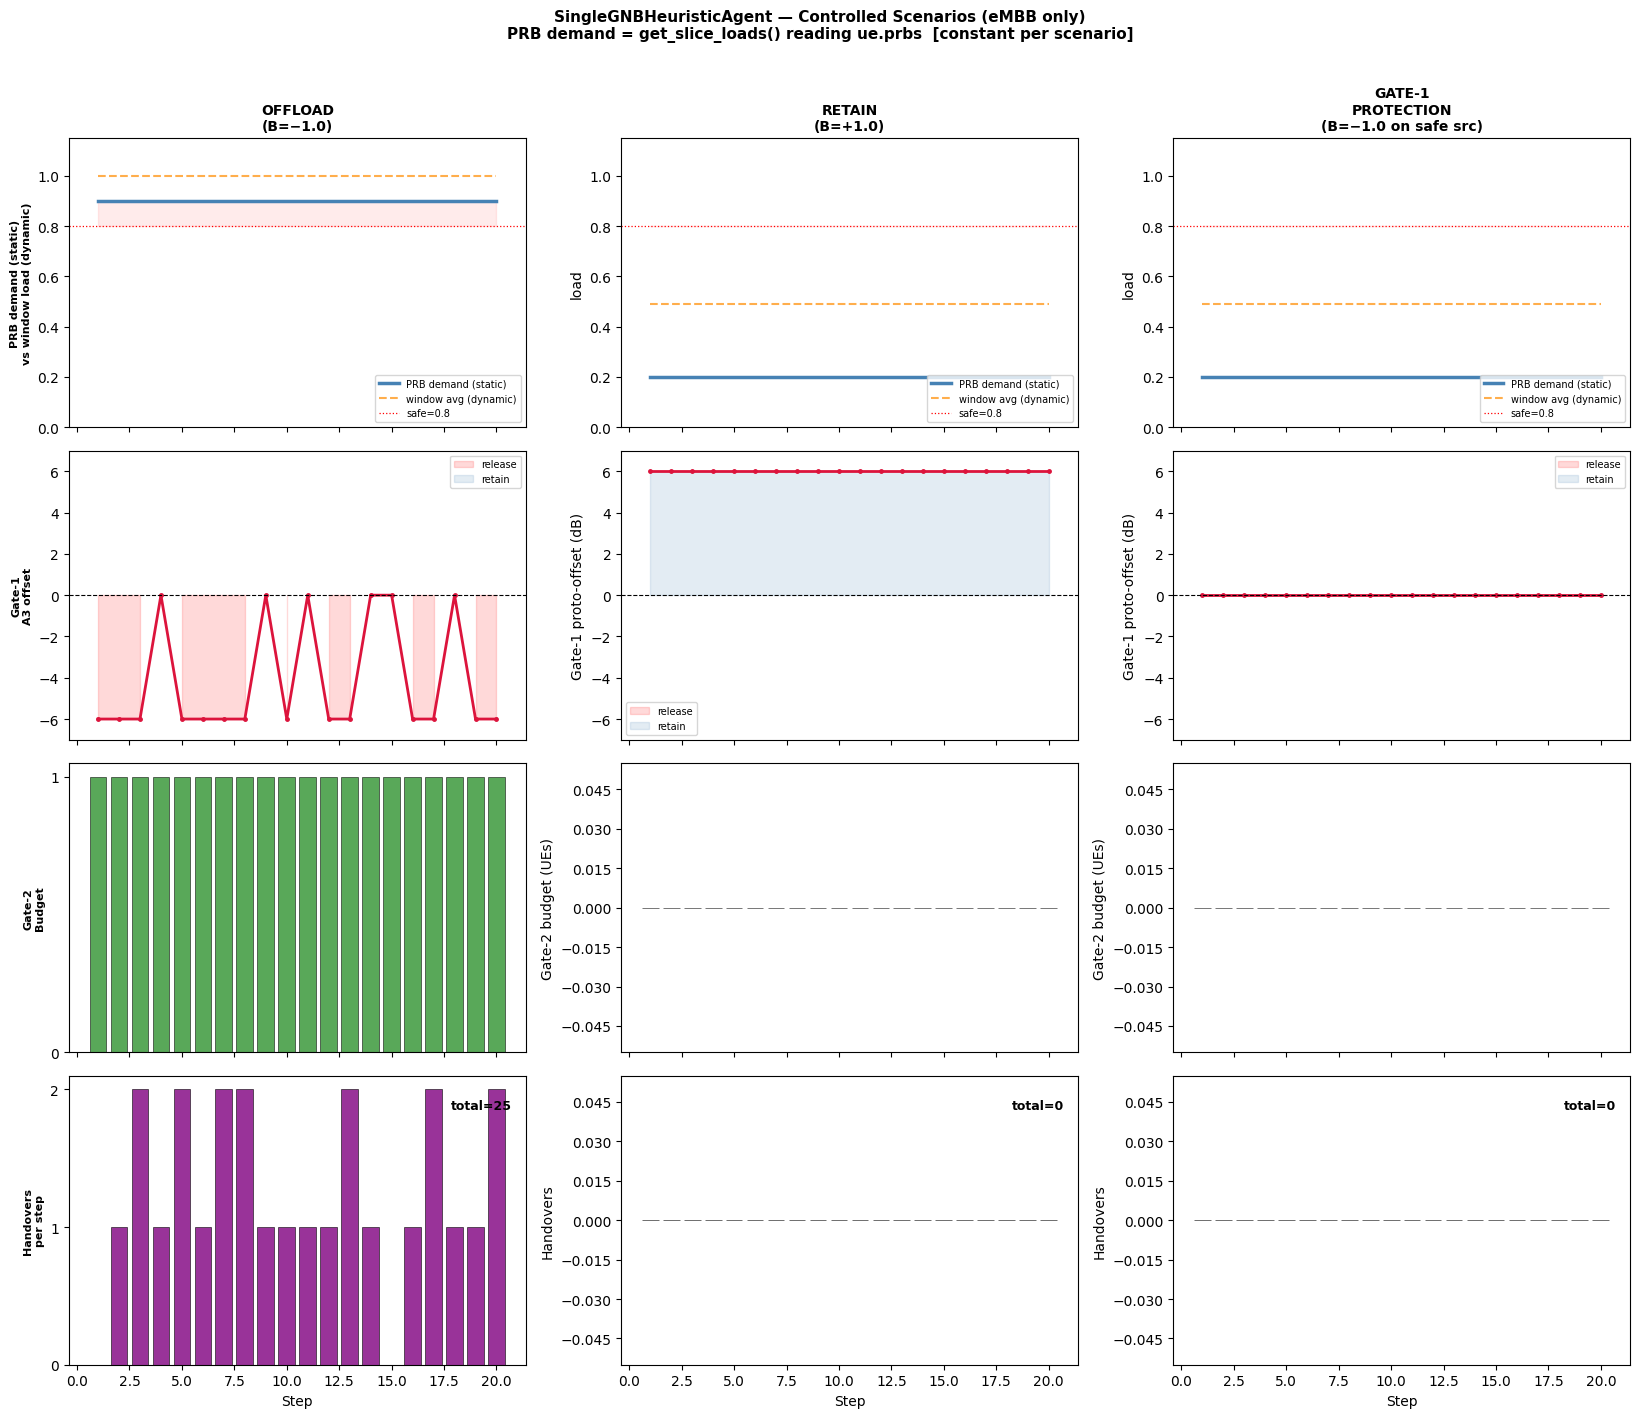

In [12]:
fig, axes = plt.subplots(
    4, len(SCENARIOS),
    figsize=(5.5 * len(SCENARIOS), 14),
    sharex=True,
)

colors = {"demand": "steelblue", "window": "darkorange", "offset": "crimson", "budget": "forestgreen", "ho": "purple"}

for col, (label, snapshot, bval, desc) in enumerate(SCENARIOS):
    r    = results[label]["rec"]
    xs   = list(range(1, len(r["prb_demand"]) + 1))

    # Row 0 — PRB demand (static) vs window load (dynamic)
    ax = axes[0, col]
    ax.plot(xs, r["prb_demand"], color=colors["demand"], lw=2.5, label="PRB demand (static)", zorder=3)
    ax.plot(xs, r["window_load"], color=colors["window"], lw=1.5, ls="--", alpha=0.7, label="window avg (dynamic)")
    ax.axhline(SAFE_LOAD, color="red", lw=0.9, ls=":", label=f"safe={SAFE_LOAD}")
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("load")
    ax.legend(fontsize=7, loc="lower right")
    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.fill_between(xs, SAFE_LOAD, [max(d, SAFE_LOAD) for d in r["prb_demand"]],
                    color="red", alpha=0.08, label="overload zone")

    # Row 1 — Gate-1 proto-offset
    ax = axes[1, col]
    ax.plot(xs, r["proto_off"], color=colors["offset"], lw=2, marker=".", ms=5)
    ax.axhline(0, color="black", lw=0.8, ls="--")
    ax.set_ylim(-7, 7)
    ax.set_ylabel("Gate-1 proto-offset (dB)")
    ax.fill_between(xs, r["proto_off"], 0,
                    where=[v < 0 for v in r["proto_off"]], color="red",    alpha=0.15, label="release")
    ax.fill_between(xs, r["proto_off"], 0,
                    where=[v > 0 for v in r["proto_off"]], color="steelblue", alpha=0.15, label="retain")
    ax.legend(fontsize=7)

    # Row 2 — Gate-2 budget
    ax = axes[2, col]
    ax.bar(xs, r["budget"], color=colors["budget"], alpha=0.75, edgecolor="black", lw=0.5)
    ax.set_ylabel("Gate-2 budget (UEs)")
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

    # Row 3 — Handovers per step
    ax = axes[3, col]
    ax.bar(xs, r["ho"], color=colors["ho"], alpha=0.80, edgecolor="black", lw=0.5)
    ax.set_ylabel("Handovers")
    ax.set_xlabel("Step")
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    total_ho = sum(r["ho"])
    ax.text(0.97, 0.92, f"total={total_ho}", transform=ax.transAxes,
            ha="right", va="top", fontsize=9, fontweight="bold")

# Row labels
row_labels = [
    "PRB demand (static)\nvs window load (dynamic)",
    "Gate-1\nA3 offset",
    "Gate-2\nBudget",
    "Handovers\nper step",
]
for row, lbl in enumerate(row_labels):
    axes[row, 0].set_ylabel(lbl, fontsize=8, fontweight="bold")

fig.suptitle(
    "SingleGNBHeuristicAgent — Controlled Scenarios (eMBB only)\n"
    "PRB demand = get_slice_loads() reading ue.prbs  [constant per scenario]",
    fontsize=11, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.show()

---
## 5 — PRB Demand Stability Verification

`_seed_case_prbs()` is called every `env.step()` — it resets `ue.prbs` to `scenario.local_load × n_prbs`.
So `get_slice_loads()` should return the **same constant value** every step, even when handovers occur.

In [13]:
print(f"{'Scenario':<45}  {'demand min':>10}  {'demand max':>10}  {'constant?':>10}  total_HO")
print("─" * 90)

for label, snapshot, bval, desc in SCENARIOS:
    r    = results[label]["rec"]
    dmin = min(r["prb_demand"])
    dmax = max(r["prb_demand"])
    is_const = (dmax - dmin) < 0.01
    total_ho = sum(r["ho"])
    lbl = label.replace("\n", " ")
    print(f"  {lbl:<43}  {dmin:>10.3f}  {dmax:>10.3f}  {'✓ YES' if is_const else '✗ NO':>10}  {total_ho:>8}")

print()
print("Key insight:")
print("  • PRB demand is constant → reflects traffic DEMAND (scenario parameter)")
print("  • Window load is dynamic → reflects actual radio UTILIZATION (scheduler output)")
print("  • The heuristic uses window load for Gate-1/2, but the UPPER expert uses demand")
print("  • Handovers change n_ues per gNB but _seed_case_prbs() re-distributes demand")
print("    to remaining UEs so the TOTAL demand stays constant at the source")

Scenario                                       demand min  demand max   constant?  total_HO
──────────────────────────────────────────────────────────────────────────────────────────
  OFFLOAD (B=−1.0)                                  0.900       0.900       ✓ YES        25
  RETAIN (B=+1.0)                                   0.200       0.200       ✓ YES         0
  GATE-1 PROTECTION (B=−1.0 on safe src)            0.200       0.200       ✓ YES         0

Key insight:
  • PRB demand is constant → reflects traffic DEMAND (scenario parameter)
  • Window load is dynamic → reflects actual radio UTILIZATION (scheduler output)
  • The heuristic uses window load for Gate-1/2, but the UPPER expert uses demand
  • Handovers change n_ues per gNB but _seed_case_prbs() re-distributes demand
    to remaining UEs so the TOTAL demand stays constant at the source


---
## 6 — Gate Summary: What Each Scenario Proves

In [14]:
print("Two-gate handover control summary\n")
print(f"  {'Scenario':<30}  {'demand':>7}  {'safe':>5}  {'overloaded':>10}  {'Gate-1 offset':>14}  {'Gate-2 budget':>14}  {'result':>10}")
print("  " + "─" * 95)

for label, snapshot, bval, desc in SCENARIOS:
    r         = results[label]["rec"]
    demand    = r["prb_demand"][0]
    over      = demand > SAFE_LOAD
    p1        = r["proto_off"][0]
    bg1       = r["budget"][0]
    total_ho  = sum(r["ho"])
    lbl       = label.replace("\n", " ")

    g1_str = f"{p1:+.1f} dB"
    g2_str = f"{bg1} UEs"
    res    = f"{total_ho} HOs" if total_ho > 0 else "0 HOs ✓"

    print(f"  {lbl:<30}  {demand:>7.2f}  {SAFE_LOAD:>5.2f}  {'YES ←OVER' if over else 'NO  ←safe':>10}  {g1_str:>14}  {g2_str:>14}  {res:>10}")

print()
print("Gate-1 logic (coordinated_neighbor_offsets):")
print("  source_pressure = max(0, demand - safe_load) / headroom_scale")
print("  → offset = -6 × source_pressure × neighbor_share     if pressure > 0 and neighbor has headroom")
print("  → offset = 0                                          if pressure = 0  (demand ≤ safe_load)")
print()
print("Gate-2 logic (_compute_directional_budgets):")
print("  bias_budget   = ceil( |bias| × n_ues )")
print("  safe_budget   = ceil( max(0, demand - safe_load) / per_ue_demand )   → 0 if not overloaded")
print("  final_budget  = min( bias_budget, safe_budget )")

Two-gate handover control summary

  Scenario                         demand   safe  overloaded   Gate-1 offset   Gate-2 budget      result
  ───────────────────────────────────────────────────────────────────────────────────────────────
  OFFLOAD (B=−1.0)                   0.90   0.80   YES ←OVER         -6.0 dB           1 UEs      25 HOs
  RETAIN (B=+1.0)                    0.20   0.80   NO  ←safe         +6.0 dB           0 UEs     0 HOs ✓
  GATE-1 PROTECTION (B=−1.0 on safe src)     0.20   0.80   NO  ←safe         +0.0 dB           0 UEs     0 HOs ✓

Gate-1 logic (coordinated_neighbor_offsets):
  source_pressure = max(0, demand - safe_load) / headroom_scale
  → offset = -6 × source_pressure × neighbor_share     if pressure > 0 and neighbor has headroom
  → offset = 0                                          if pressure = 0  (demand ≤ safe_load)

Gate-2 logic (_compute_directional_budgets):
  bias_budget   = ceil( |bias| × n_ues )
  safe_budget   = ceil( max(0, demand - safe_load) 